# Same-start runs

Every clip here begins from one of **five saved spawn layouts**. A run with random movement has a
partner with none that started from the identical arrangement of agents, so a difference between
the two traces is the parameter and not the spawn.

The report goes: what is in the folder, the five starts, hull area over time, wall contact, the
rate of change, and finally each randomised run measured against its own no-randomness partner.

Everything is imported from `same_start.py` — no measure is reimplemented here, and hull area and
wall contacts are both read straight from the recordings, where Unity computed them at capture
time.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst

RECORDINGS = Path("../../Assets/SimulationRecordings/MatchedStart_PerceptionRad")

runs = sst.load_folder(RECORDINGS)
inv = sst.inventory(runs)

print(f"{len(runs)} clips from {RECORDINGS.name}\n")
print(sst.describe(inv))

# pandas .style needs a recent jinja2. Probe the capability rather than the import: an old
# jinja2 imports fine but pandas still refuses it, so `import jinja2` is not the right test.
# The tables are the point of these cells, the colouring is not, so degrade instead of failing.
try:
    pd.DataFrame({"x": [0]}).style.background_gradient()
    _STYLED = True
except Exception as exc:
    _STYLED = False
    print(f"unstyled tables ({exc}). Fix with:  "
          f"conda env update -n PythonAnalysis -f ../environment.yml")


def show(df, caption=None, cmap="Blues", subset=None, vmin=None, vmax=None):
    """Display a frame, colour-graded when pandas styling is available."""
    if not _STYLED:
        if caption:
            print(caption)
        display(df)
        return
    styled = df.style.background_gradient(cmap=cmap, axis=None, subset=subset,
                                          vmin=vmin, vmax=vmax)
    display(styled.set_caption(caption) if caption else styled)

320 clips from MatchedStart_PerceptionRad

random movement : 0, 40, 80
max speed       : 1.5, 4
perception radii: 16 levels, 0.15 to 3.9
                  0.15, 0.4, 0.65, 0.9, 1.15, 1.4, 1.65, 1.9, 2.15, 2.4, 2.65, 2.9, 3.15, 3.4, 3.65, 3.9
spawn layouts   : 5  (all shared by every condition)

   motion         random  maxSpeed  clips  layouts  radii  R range
   Dispersion          0       1.5     80        5     16  0.15-3.9
   Dispersion          0       4.0     80        5     16  0.15-3.9
   Dispersion         40       1.5     40        5      8  0.15-1.9
   Dispersion         40       4.0     40        5      8  2.15-3.9
   Dispersion         80       1.5     40        5      8  0.15-1.9
   Dispersion         80       4.0     40        5      8  2.15-3.9
unstyled tables (The '.style' accessor requires jinja2). Fix with:  conda env update -n PythonAnalysis -f ../environment.yml


In [2]:
design = pd.DataFrame(inv["rows"])
display(design)

print("randoms   :", inv["randoms"])
print("maxSpeeds :", inv["speeds"])
print("radii     :", inv["radii"])
print("layouts   :", [sst._short(x) for x in inv["layouts"]])

,motion,random,maxSpeed,clips,radii,layouts,R_min,R_max,batches
0,Dispersion,0,1.5,80,16,5,0.15,3.9,2
1,Dispersion,0,4.0,80,16,5,0.15,3.9,2
2,Dispersion,40,1.5,40,8,5,0.15,1.9,1
3,Dispersion,40,4.0,40,8,5,2.15,3.9,1
4,Dispersion,80,1.5,40,8,5,0.15,1.9,1
5,Dispersion,80,4.0,40,8,5,2.15,3.9,1


randoms   : [0, 40, 80]
maxSpeeds : [1.5, 4.0]
radii     : [0.15, 0.4, 0.65, 0.9, 1.15, 1.4, 1.65, 1.9, 2.15, 2.4, 2.65, 2.9, 3.15, 3.4, 3.65, 3.9]
layouts   : ['00', '01', '02', '03', '04']


### Coverage holes

A missing cell here is not a small gap: it means a randomised run has no reference at that radius,
so it cannot be compared within layout and it silently vanishes from any paired analysis.

In [3]:
grid = (pd.DataFrame([{"maxSpeed": r["speed"], "random": r["random"], "R": r["R"]}
                      for r in runs])
         .pivot_table(index="R", columns=["maxSpeed", "random"], aggfunc=len, values="R")
         .fillna(0).astype(int))

show(grid, "clips per perception radius (0 = not recorded)")

for speed in inv["speeds"]:
    ref = {r["R"] for r in sst.select(runs, speed=speed, random=0)}
    rnd = {r["R"] for r in runs if r["speed"] == speed and r["random"] > 0}
    if ref - rnd:
        print(f"maxSpeed {speed:g}: reference only, no randomised partner at "
              f"{sorted(ref - rnd)}")
    if rnd - ref:
        print(f"maxSpeed {speed:g}: randomised only, no reference at {sorted(rnd - ref)}")

clips per perception radius (0 = not recorded)


maxSpeed 1.5       4.0      
random    0  40 80  0  40 80
R                           
0.15       5  5  5   5  0  0
0.40       5  5  5   5  0  0
0.65       5  5  5   5  0  0
0.90       5  5  5   5  0  0
1.15       5  5  5   5  0  0
1.40       5  5  5   5  0  0
1.65       5  5  5   5  0  0
1.90       5  5  5   5  0  0
2.15       5  0  0   5  5  5
2.40       5  0  0   5  5  5
2.65       5  0  0   5  5  5
2.90       5  0  0   5  5  5
3.15       5  0  0   5  5  5
3.40       5  0  0   5  5  5
3.65       5  0  0   5  5  5
3.90       5  0  0   5  5  5

maxSpeed 1.5: reference only, no randomised partner at [2.15, 2.4, 2.65, 2.9, 3.15, 3.4, 3.65, 3.9]
maxSpeed 4: reference only, no randomised partner at [0.15, 0.4, 0.65, 0.9, 1.15, 1.4, 1.65, 1.9]


## 2. The five starting positions

Crosses are the layout as saved at spawn. Rings are the first *recorded* frame of one run per
condition on that layout.

They do not quite coincide for the randomised conditions, and that is expected rather than a
pairing failure: capture begins a few frames after motion is enabled, and random movement acts
immediately. The drift is quantified underneath — about one agent diameter, with no effect on the
frame-0 hull area.

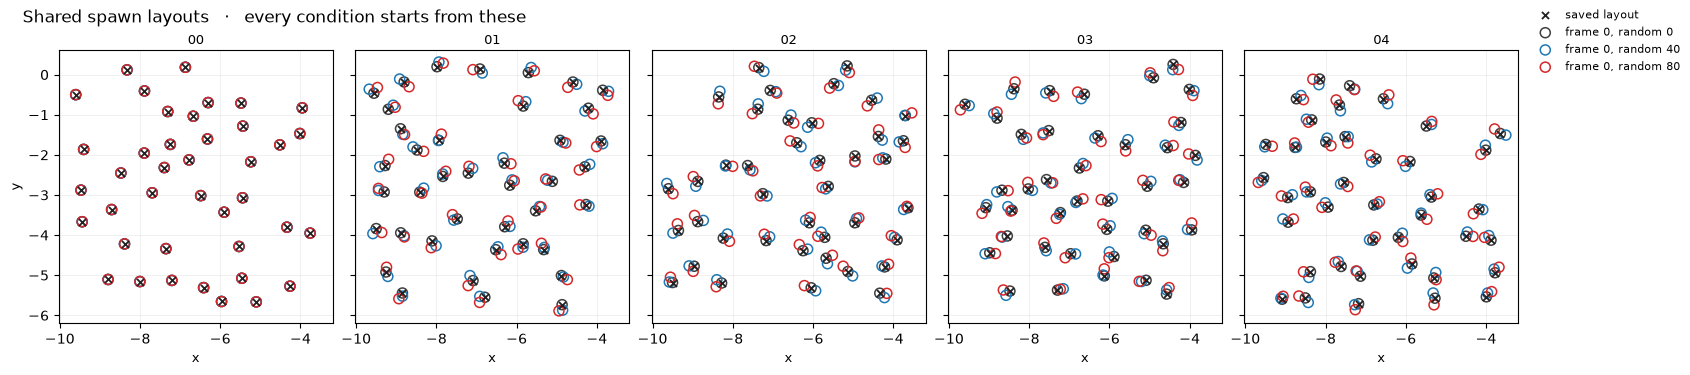

In [4]:
layouts = sst.load_layouts(runs, RECORDINGS)
fig = sst.layout_figure(runs, layouts)
plt.show()

In [5]:
rows = []
for run in runs:
    saved = layouts.get(run["layout"])
    if saved is None:
        continue
    first = sst.frame_zero(run)
    if first is None or len(first) != len(saved):
        continue
    d = np.hypot(*(first - saved).T)
    rows.append({"random": run["random"], "maxSpeed": run["speed"],
                 "mean_drift_u": d.mean(), "max_drift_u": d.max(),
                 "hull_at_frame0": run["areas"][0]})

drift = pd.DataFrame(rows).groupby(["random", "maxSpeed"]).mean().round(3)
display(drift)
print("spawn layouts are identical by construction; the drift is capture latency, not spawn "
      "variation.\nFrame-0 hull area is unchanged across conditions, so it does not bias the "
      "comparison.")

mean_drift_u  max_drift_u  hull_at_frame0
random maxSpeed                                           
0      1.5              0.019        0.039          25.264
       4.0              0.019        0.039          25.264
40     1.5              0.116        0.159          25.027
       4.0              0.136        0.237          25.608
80     1.5              0.155        0.180          25.038
       4.0              0.256        0.382          25.617

spawn layouts are identical by construction; the drift is capture latency, not spawn variation.
Frame-0 hull area is unchanged across conditions, so it does not bias the comparison.


## 3. Hull area over time, per layout

One panel per starting layout, colour is perception radius, line style is the random level. The
smooth curves that rise and flatten early are the no-randomness references. The rough curves that
keep climbing are the randomised runs — at this speed most never settle inside the 60 s window.

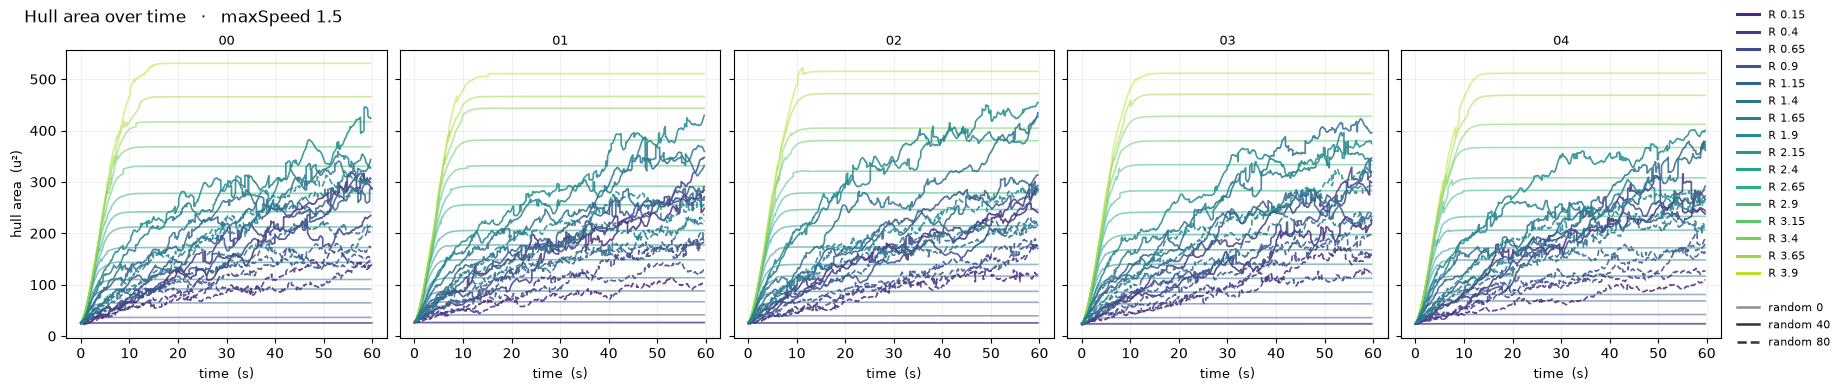

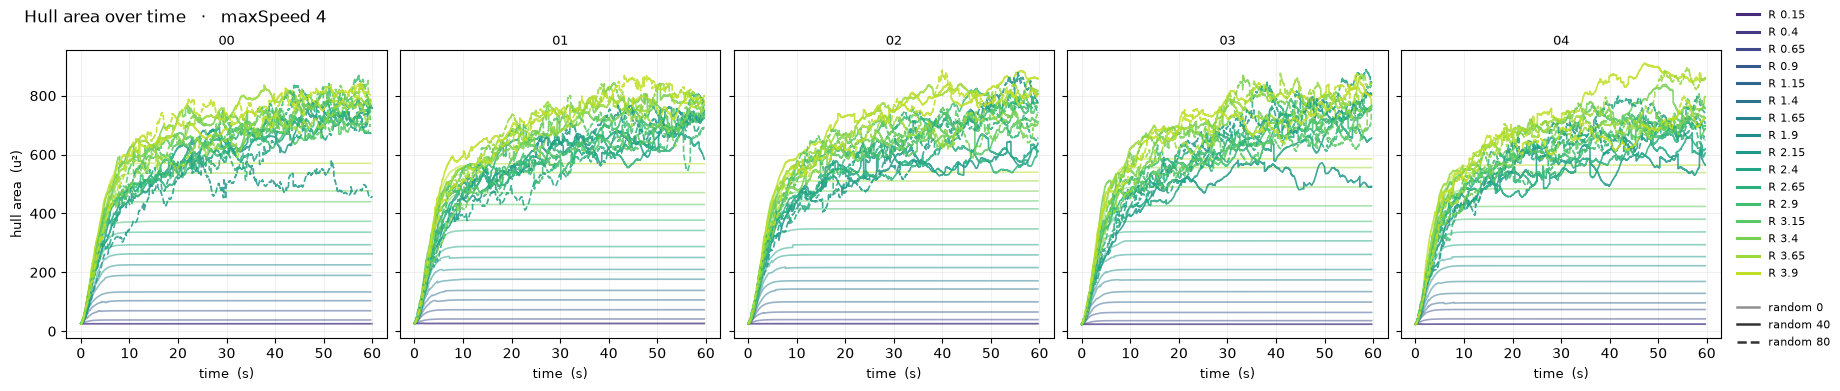

In [6]:
for speed in inv["speeds"]:
    sst.hull_figure(runs, speed)
    plt.show()

Normalising each trace by its own frame-0 area puts every radius on one scale, which makes the
*shape* comparable when the absolute areas differ by an order of magnitude.

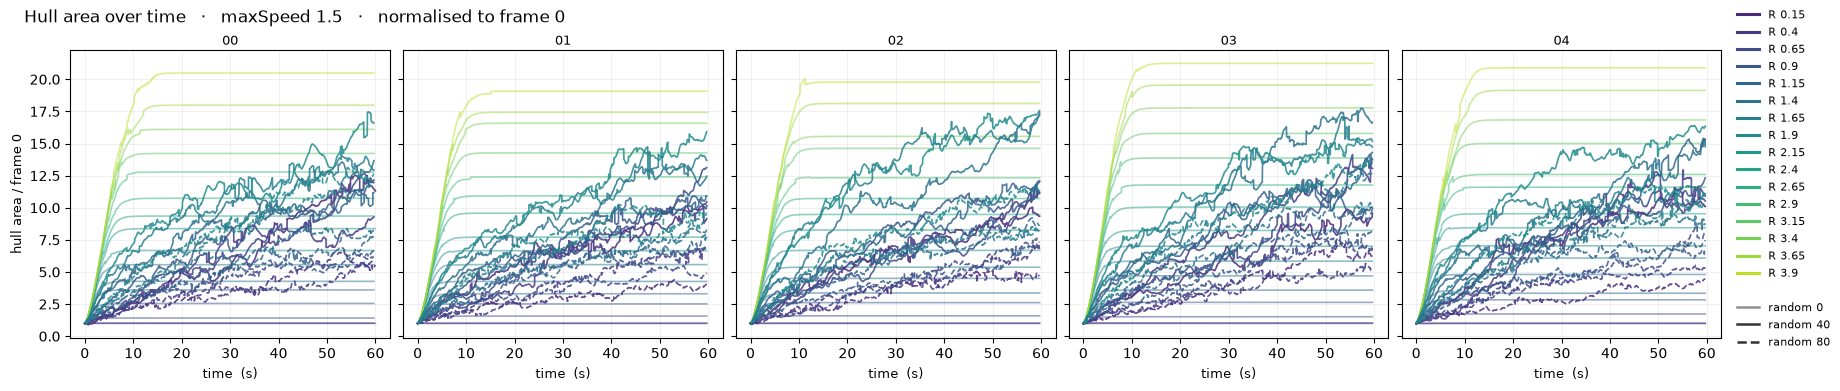

In [7]:
sst.hull_figure(runs, inv["speeds"][0], normalise=True)
plt.show()

## 4. Wall contact

Cumulative share of the swarm that has touched a wall at least once. This is the confound to watch:
once agents are riding the boundary, the hull is reporting the arena rather than the swarm.

Contacts are recorded in Unity against the walls that were **active for that run**, so a motion
type with walls disabled is already accounted for. Note it is a geometric test rather than a
physics event — agents are moved by writing `transform.position`, so collision callbacks never
see a sweep.

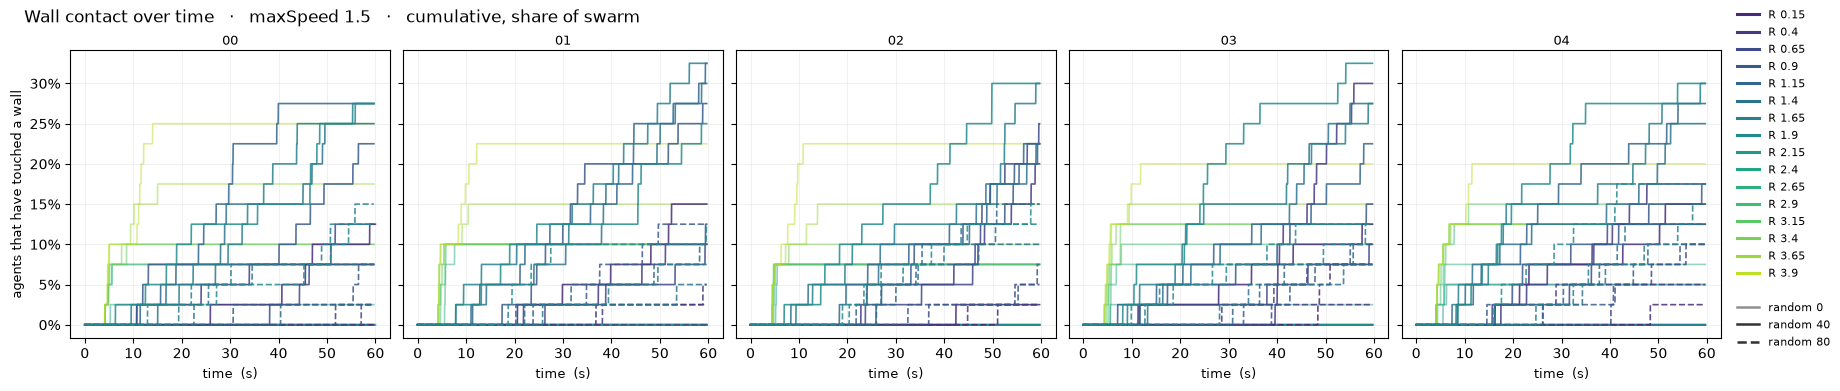

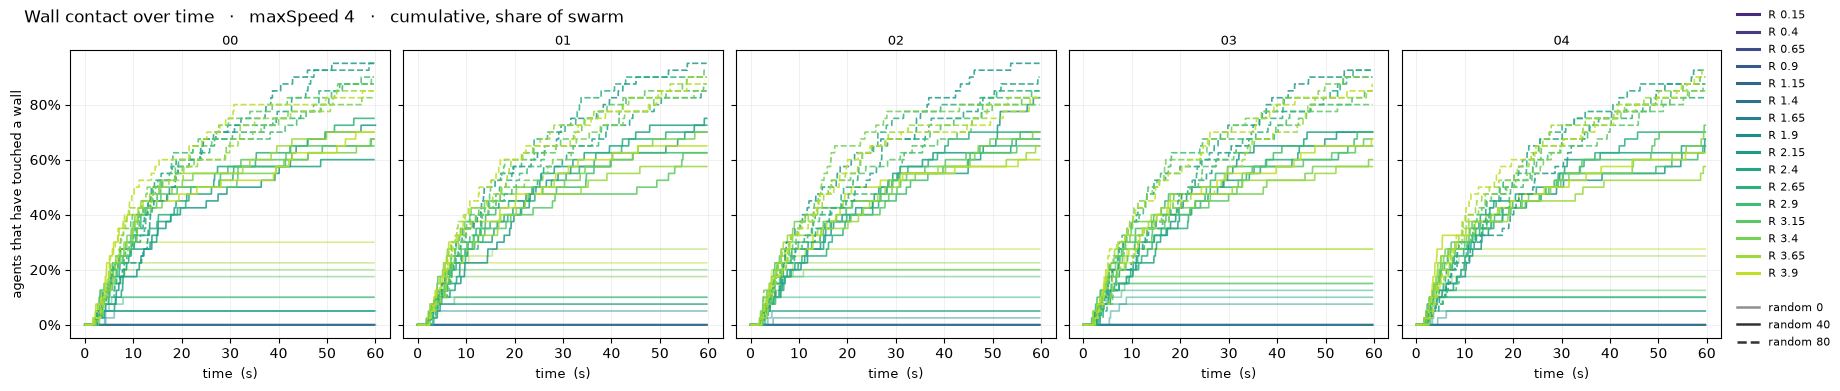

In [8]:
for speed in inv["speeds"]:
    sst.contacts_figure(runs, speed)
    plt.show()

In [9]:
budget = 0.20
rows = []
for run in runs:
    n = max(int(run["header"].get("agentCount", 1)), 1)
    rows.append({"maxSpeed": run["speed"], "random": run["random"], "R": run["R"],
                 "touched_by_end": run["unique"][-1] / n})

walls = (pd.DataFrame(rows).groupby(["maxSpeed", "random", "R"])["touched_by_end"]
           .mean().unstack("R").round(2))
show(walls, f"share of swarm that touched a wall by the end of the clip (budget {budget:.0%})",
     cmap="Reds", vmin=0, vmax=1)

share of swarm that touched a wall by the end of the clip (budget 20%)


R                0.15  0.40  0.65  0.90  1.15  1.40  1.65  1.90  2.15  2.40  \
maxSpeed random                                                               
1.5      0       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.03   
         40      0.12  0.17  0.14  0.21  0.26  0.26  0.30  0.29   NaN   NaN   
         80      0.03  0.04  0.05  0.10  0.10  0.08  0.12  0.14   NaN   NaN   
4.0      0       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.04  0.06  0.08   
         40       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  0.74  0.67   
         80       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  0.94  0.89   

R                2.65  2.90  3.15  3.40  3.65  3.90  
maxSpeed random                                      
1.5      0       0.08  0.10  0.11  0.11  0.15  0.22  
         40       NaN   NaN   NaN   NaN   NaN   NaN  
         80       NaN   NaN   NaN   NaN   NaN   NaN  
4.0      0       0.11  0.12  0.17  0.18  0.25  0.27  
         40      0.70  0.67  0.66  0.68  0.62  0.65  
         80      0.88  0.88  0.86  0.84  0.87  0.86

## 5. Rate of change, d(hull)/dt

The same series differentiated over a rolling window. Hull area tells you *where* the swarm got;
its slope tells you *whether it is still going*, which is the only way to distinguish a genuine
steady state from a run that simply ran out of time.

Read it as: the references pulse and return to zero — that return **is** the plateau. The
randomised runs sit at a positive value for the whole clip and never come back to zero.

The window is 3 s here rather than the 1 s used by `steady_state.find_plateau`; at 1 s the
randomised traces are a solid band of noise.

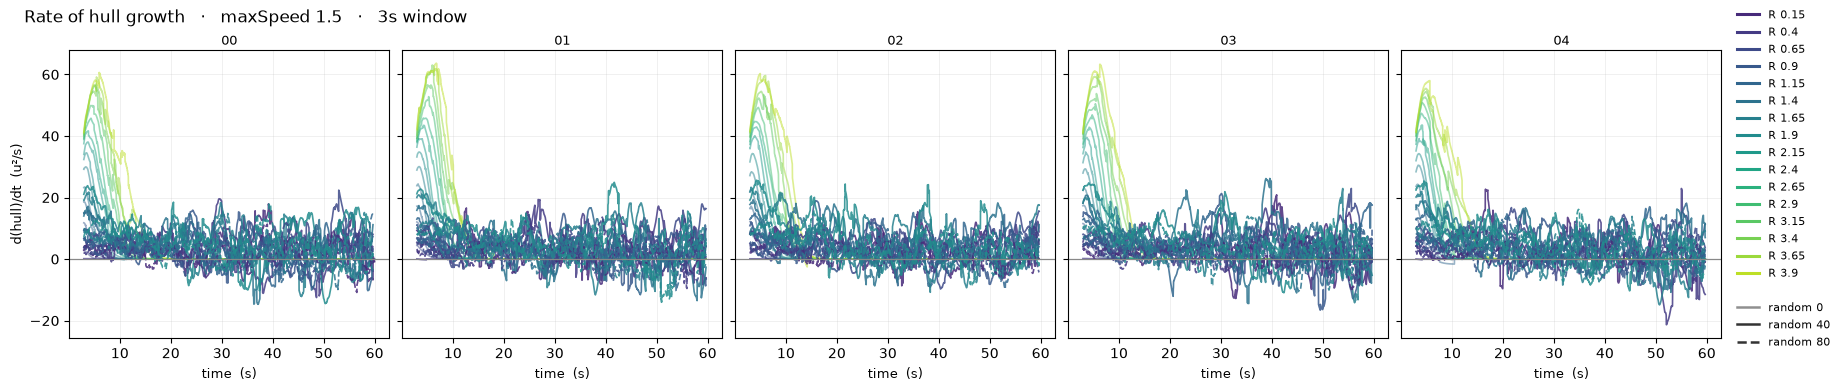

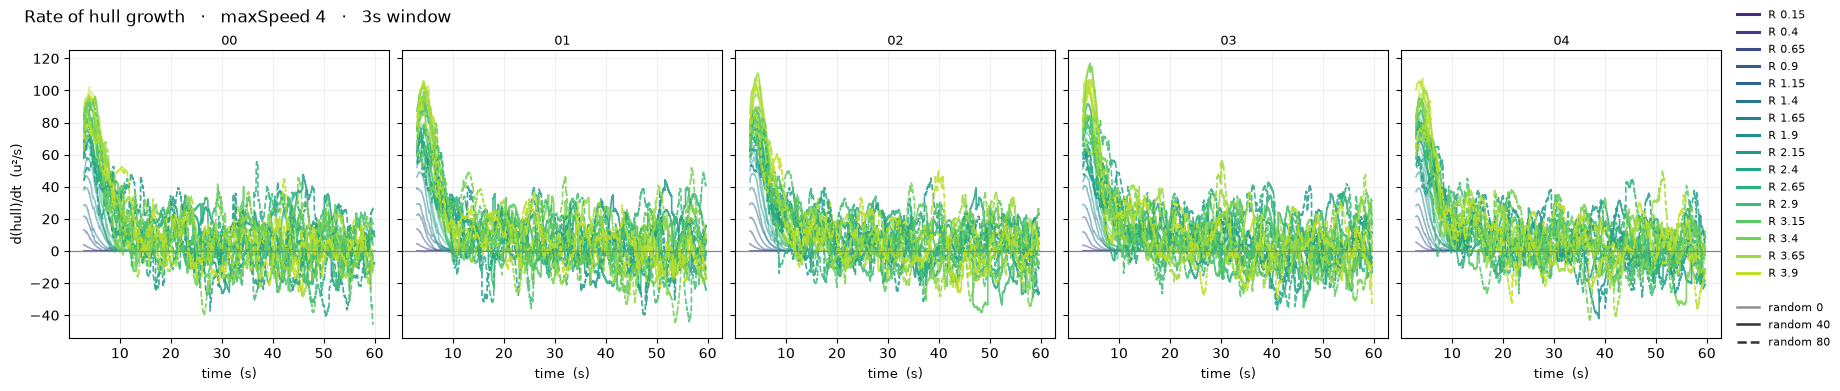

In [10]:
for speed in inv["speeds"]:
    sst.rate_figure(runs, speed)
    plt.show()

Zooming to a few radii on one layout makes the contrast explicit.

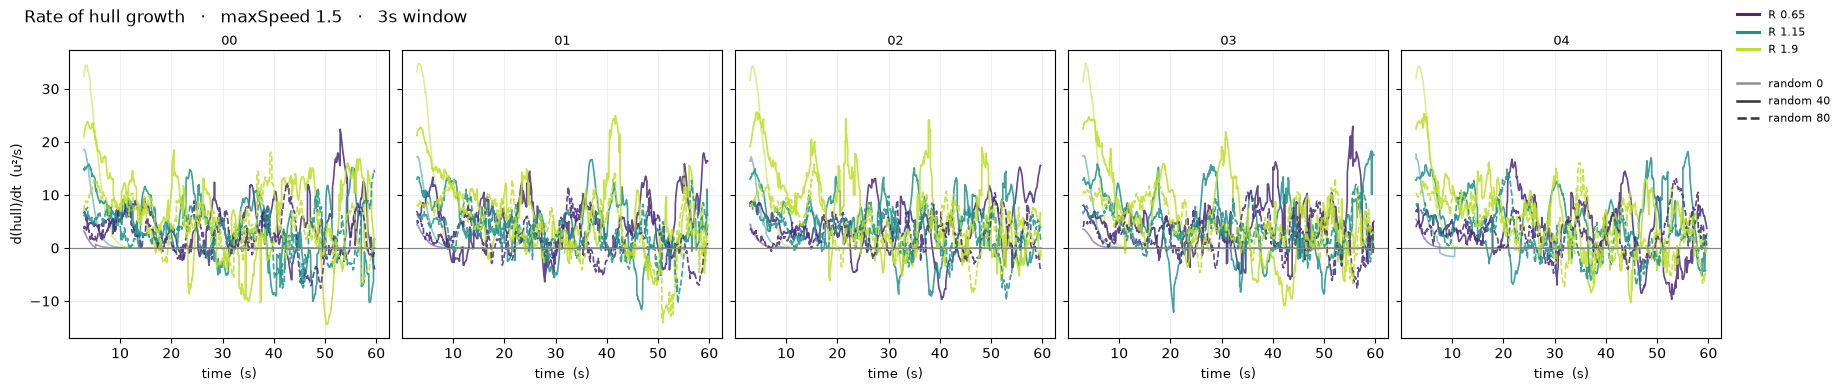

R 0.65  random 0    peak d(hull)/dt    3.2 u²/s   mean over last 20%   0.00 u²/s   back at zero -> settled
R 0.65  random 40   peak d(hull)/dt   22.4 u²/s   mean over last 20%   7.46 u²/s   still growing
R 0.65  random 80   peak d(hull)/dt   12.2 u²/s   mean over last 20%   0.57 u²/s   back at zero -> settled
R 1.15  random 0    peak d(hull)/dt   18.6 u²/s   mean over last 20%   0.00 u²/s   back at zero -> settled
R 1.15  random 40   peak d(hull)/dt   15.8 u²/s   mean over last 20%   2.43 u²/s   still growing
R 1.15  random 80   peak d(hull)/dt   14.6 u²/s   mean over last 20%   2.93 u²/s   still growing
R 1.9   random 0    peak d(hull)/dt   34.5 u²/s   mean over last 20%   0.00 u²/s   back at zero -> settled
R 1.9   random 40   peak d(hull)/dt   23.8 u²/s   mean over last 20%   4.67 u²/s   still growing
R 1.9   random 80   peak d(hull)/dt   18.0 u²/s   mean over last 20%   0.64 u²/s   back at zero -> settled


In [11]:
speed = inv["speeds"][0]
few = [R for R in (0.65, 1.15, 1.9) if R in inv["radii"]]
sst.rate_figure(runs, speed, radii=few)
plt.show()

for run in sorted(sst.select(runs, speed=speed, R=few, layout=inv["layouts"][0]),
                  key=lambda r: (r["R"], r["random"])):
    t, slope = sst._smooth_derivative(run["times"], run["areas"], 3.0)
    tail = slope[int(len(slope) * 0.8):]
    print(f"R {run['R']:<5g} random {run['random']:<3d}  "
          f"peak d(hull)/dt {slope.max():6.1f} u²/s   "
          f"mean over last 20% {tail.mean():6.2f} u²/s   "
          f"{'back at zero -> settled' if abs(tail.mean()) < 1 else 'still growing'}")

## 6. Against the no-randomness partner

The point of the shared starts. Each randomised run is divided by the reference that began from
the **same layout at the same radius**, so the ratio is a within-layout measure with the spawn
divided out. A value of 1 means randomness bought no extra dispersion.

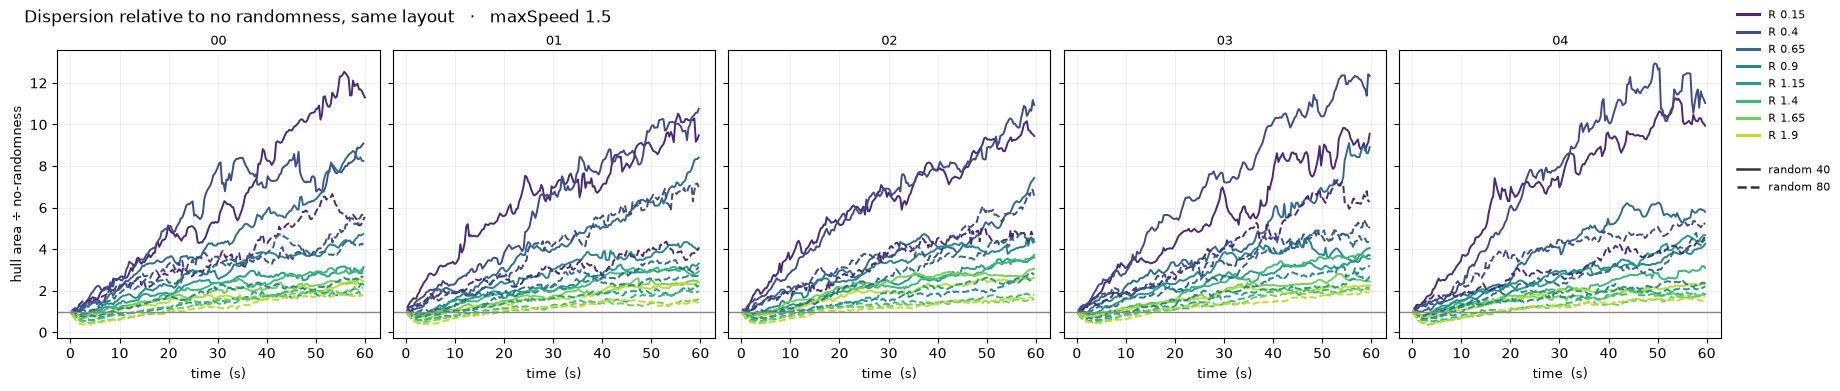

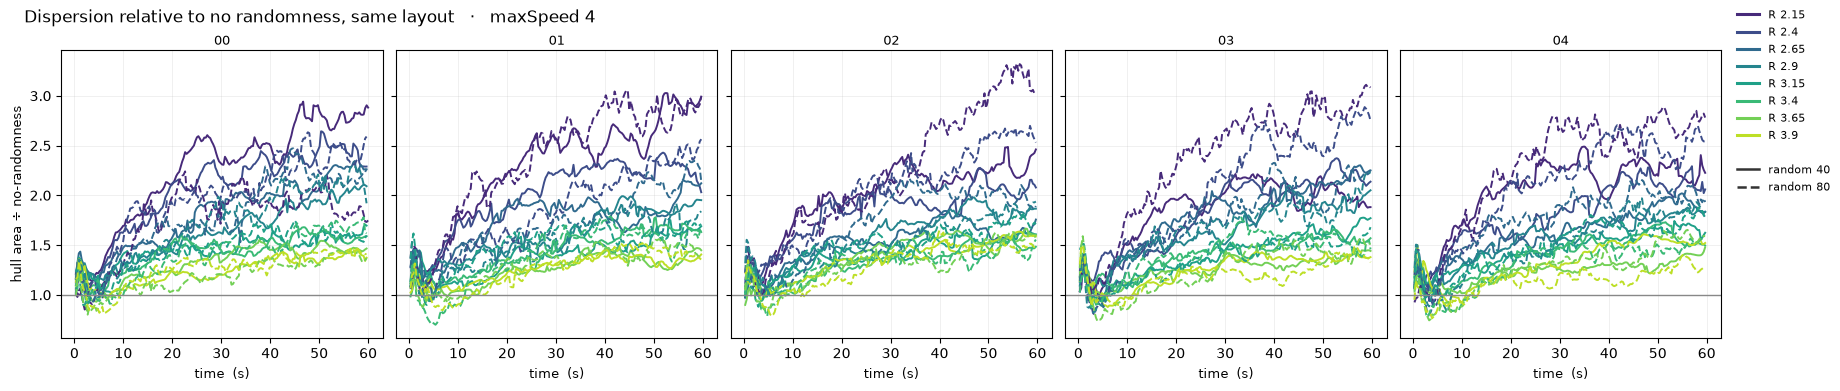

In [12]:
for speed in inv["speeds"]:
    sst.reference_figure(runs, speed, mode="ratio")
    plt.show()

Both traces drawn together, rather than as a ratio, for the case where the absolute areas matter.
The thick pale line in each colour is the reference.

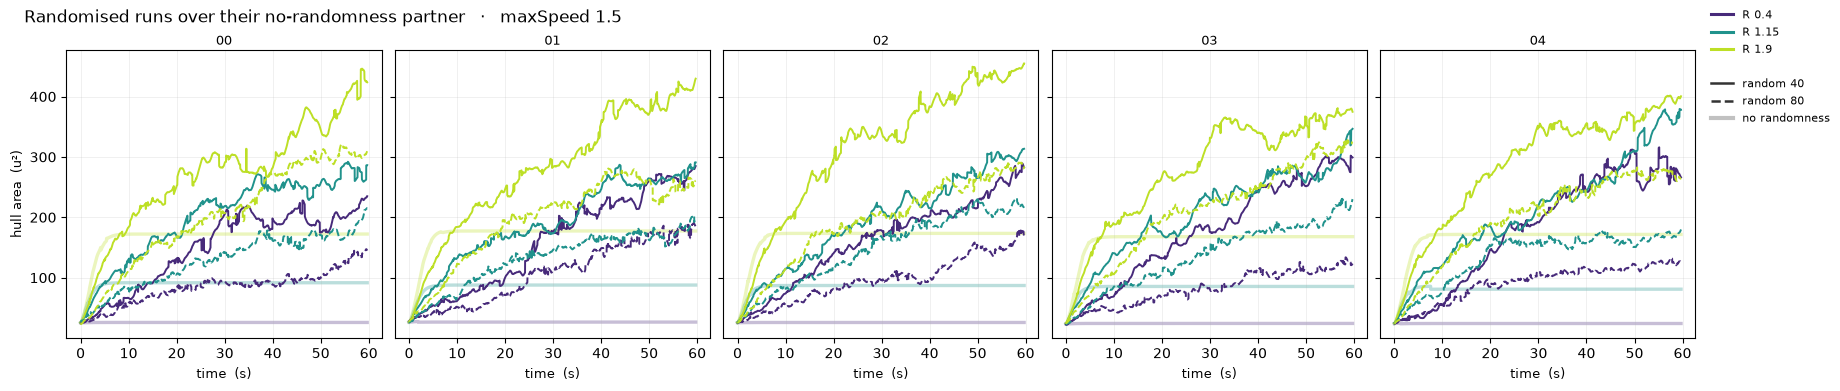

In [13]:
sst.reference_figure(runs, inv["speeds"][0], mode="overlay",
                     radii=[R for R in (0.4, 1.15, 1.9) if R in inv["radii"]])
plt.show()

## 7. Summary

Panel A is the peak hull area each condition reached; panel B is that peak divided by its own
no-randomness partner.

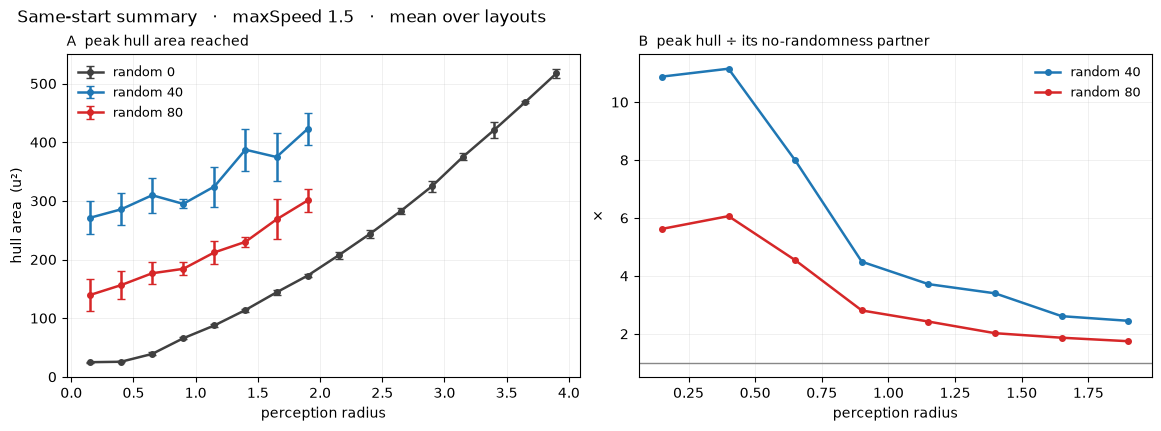

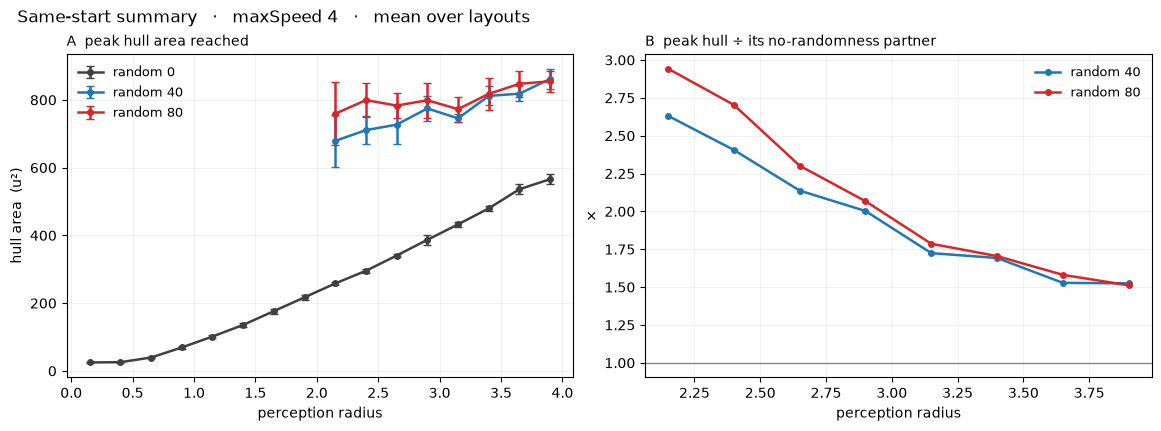

In [14]:
for speed in inv["speeds"]:
    sst.summary_figure(runs, speed)
    plt.show()

In [15]:
rows = []
for run in runs:
    ref = sst.select(runs, speed=run["speed"], R=run["R"], layout=run["layout"], random=0)
    rows.append({
        "maxSpeed": run["speed"], "random": run["random"], "R": run["R"],
        "peak_hull": run["areas"].max(),
        "vs_reference": run["areas"].max() / ref[0]["areas"].max() if ref else np.nan,
    })

summary = (pd.DataFrame(rows).groupby(["maxSpeed", "random", "R"])
             .mean().round(2).reset_index())
pivot = summary.pivot_table(index=["maxSpeed", "R"], columns="random", values="peak_hull")
show(pivot, "peak hull area (u²), mean over the five layouts", cmap="viridis")

peak hull area (u²), mean over the five layouts


random             0       40      80
maxSpeed R                           
1.5      0.15   24.91  271.14  139.45
         0.40   25.68  285.50  156.31
         0.65   39.00  309.63  176.56
         0.90   65.72  294.86  184.08
         1.15   87.54  324.46  212.10
         1.40  113.90  387.24  230.14
         1.65  144.02  374.74  268.41
         1.90  172.51  422.69  300.65
         2.15  207.30     NaN     NaN
         2.40  243.61     NaN     NaN
         2.65  282.89     NaN     NaN
         2.90  325.00     NaN     NaN
         3.15  375.36     NaN     NaN
         3.40  420.95     NaN     NaN
         3.65  468.54     NaN     NaN
         3.90  517.39     NaN     NaN
4.0      0.15   24.91     NaN     NaN
         0.40   25.65     NaN     NaN
         0.65   39.43     NaN     NaN
         0.90   69.10     NaN     NaN
         1.15  101.39     NaN     NaN
         1.40  135.72     NaN     NaN
         1.65  176.40     NaN     NaN
         1.90  217.15     NaN     NaN
         2.15  258.12  679.00  759.08
         2.40  295.51  710.83  799.50
         2.65  340.40  726.91  783.21
         2.90  386.99  774.73  799.02
         3.15  432.50  745.46  772.61
         3.40  479.77  811.80  817.82
         3.65  536.29  818.36  847.60
         3.90  565.97  861.93  854.82

### What the numbers say

Read the `random 80 / random 40` column below before drawing the obvious conclusion about
randomness.

In [16]:
ratio = pivot.copy()
if 40 in ratio.columns and 80 in ratio.columns:
    ratio["80 / 40"] = (ratio[80] / ratio[40]).round(2)
    show(ratio.dropna(subset=["80 / 40"]), "below 1 means the noisier swarm dispersed LESS",
         cmap="coolwarm_r", subset=["80 / 40"], vmin=0.4, vmax=1.6)

    low = ratio.dropna(subset=["80 / 40"]).loc[1.5, "80 / 40"] if 1.5 in \
        ratio.dropna(subset=["80 / 40"]).index.get_level_values(0) else None
    if low is not None:
        print(f"maxSpeed 1.5: random 80 reaches {low.min():.0%} to {low.max():.0%} of "
              f"random 40's dispersion, at every radius tested.")

below 1 means the noisier swarm dispersed LESS


random              0      40      80  80 / 40
maxSpeed R                                    
1.5      0.15   24.91  271.14  139.45     0.51
         0.40   25.68  285.50  156.31     0.55
         0.65   39.00  309.63  176.56     0.57
         0.90   65.72  294.86  184.08     0.62
         1.15   87.54  324.46  212.10     0.65
         1.40  113.90  387.24  230.14     0.59
         1.65  144.02  374.74  268.41     0.72
         1.90  172.51  422.69  300.65     0.71
4.0      2.15  258.12  679.00  759.08     1.12
         2.40  295.51  710.83  799.50     1.12
         2.65  340.40  726.91  783.21     1.08
         2.90  386.99  774.73  799.02     1.03
         3.15  432.50  745.46  772.61     1.04
         3.40  479.77  811.80  817.82     1.01
         3.65  536.29  818.36  847.60     1.04
         3.90  565.97  861.93  854.82     0.99

maxSpeed 1.5: random 80 reaches 51% to 72% of random 40's dispersion, at every radius tested.


## Caveats

- **The randomised conditions mostly do not converge.** Their hulls are still climbing at the 60 s
  timeout, which is visible in section 5 as a slope that never returns to zero. Any "final" number
  for those runs is where the clip stopped, not where the swarm settled.
- **Coverage is asymmetric.** At maxSpeed 1.5 the randomised runs cover R 0.15–1.90 only; at
  maxSpeed 4 they cover R 2.15–3.90 only. There is no radius at which the two speeds can be
  compared under randomness.
- **The large radii are arena-limited.** Above R ≈ 2.4 even the reference has agents on the walls
  by its plateau, so hull area there is partly a measurement of the box.
- **Frame 0 is not exactly the spawn** for randomised runs, by roughly one agent diameter. Section 2
  quantifies it. Fixing it properly means starting trajectory capture before motion is enabled.